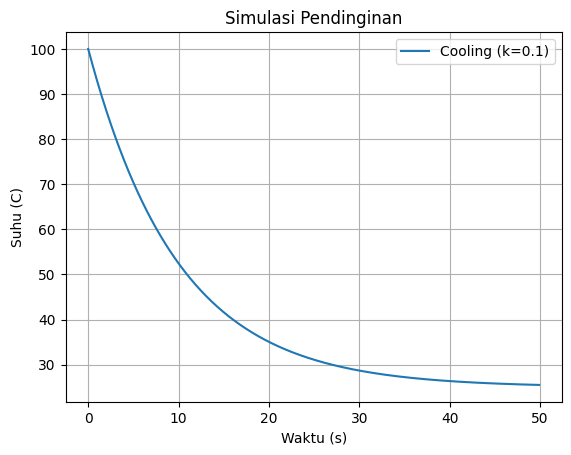

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter awal
T0 = 100  # Suhu awal benda (derajat Celsius)
Tamb = 25  # Suhu lingkungan (derajat Celsius)
k = 0.1   # Konstanta laju pendinginan
dt = 0.1  # Langkah waktu
t_max = 50  # Waktu simulasi maksimum

# Inisialisasi array
time = np.arange(0, t_max, dt)
T = np.zeros(len(time))
T[0] = T0

# Simulasi dengan metode Euler (pendinginan)
for i in range(1, len(time)):
    dT_dt = -k * (T[i-1] - Tamb)
    T[i] = T[i-1] + dT_dt * dt

# Plot hasil
plt.plot(time, T, label=f'Cooling (k={k})')
plt.xlabel('Waktu (s)')
plt.ylabel('Suhu (C)')
plt.title('Simulasi Pendinginan')
plt.legend()
plt.grid()
plt.show()

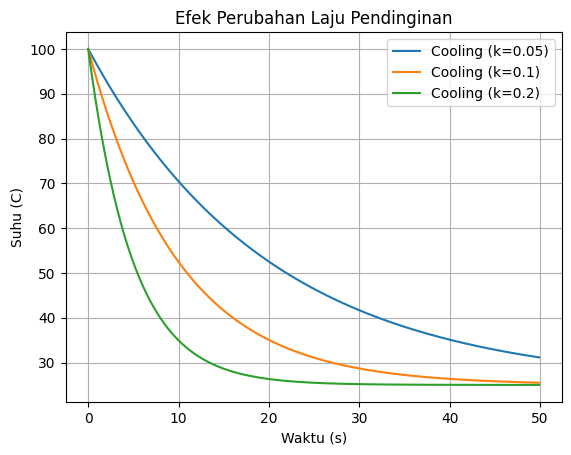

In [2]:
# Simulasi dengan laju pendinginan berbeda
k_values = [0.05, 0.1, 0.2]
for k in k_values:
    T = np.zeros(len(time))
    T[0] = T0
    for i in range(1, len(time)):
        dT_dt = -k * (T[i-1] - Tamb)
        T[i] = T[i-1] + dT_dt * dt
    plt.plot(time, T, label=f'Cooling (k={k})')

plt.xlabel('Waktu (s)')
plt.ylabel('Suhu (C)')
plt.title('Efek Perubahan Laju Pendinginan')
plt.legend()
plt.grid()
plt.show()

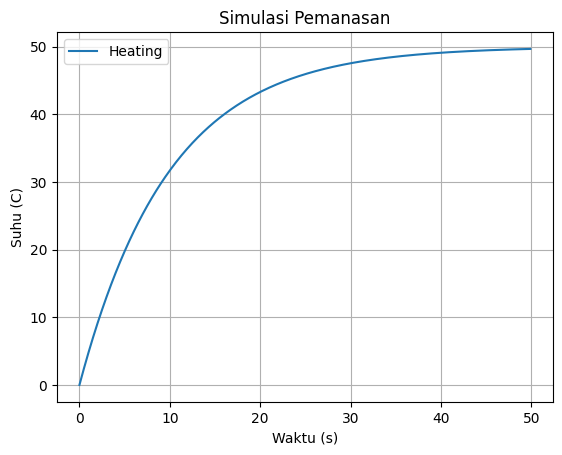

In [3]:
# Simulasi pemanasan
T = np.zeros(len(time))
T[0] = 0  # Suhu awal lebih rendah dari lingkungan
Tamb = 50  # Suhu lingkungan lebih tinggi
k = 0.1

for i in range(1, len(time)):
    dT_dt = k * (Tamb - T[i-1])
    T[i] = T[i-1] + dT_dt * dt

plt.plot(time, T, label='Heating')
plt.xlabel('Waktu (s)')
plt.ylabel('Suhu (C)')
plt.title('Simulasi Pemanasan')
plt.legend()
plt.grid()
plt.show()

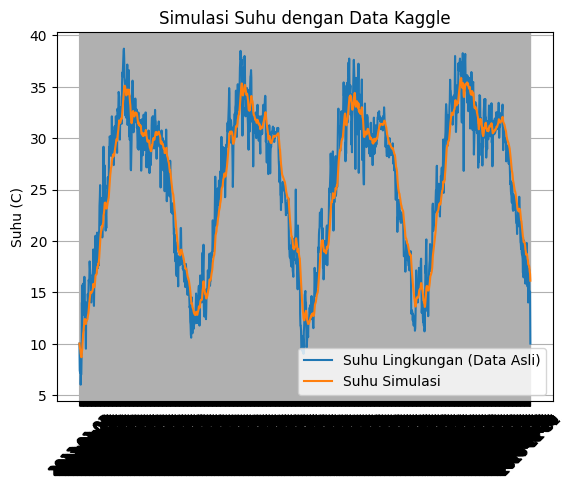

In [4]:
import pandas as pd

# Membaca dataset Kaggle
data = pd.read_csv('DailyDelhiClimateTrain.csv')
meantemp = data['meantemp'].values  # Suhu rata-rata harian

# Simulasi dengan suhu lingkungan dari dataset
T = np.zeros(len(meantemp))
T[0] = meantemp[0]  # Suhu awal dari data pertama
k = 0.1

for i in range(1, len(meantemp)):
    dT_dt = -k * (T[i-1] - meantemp[i])  # Suhu lingkungan berubah setiap hari
    T[i] = T[i-1] + dT_dt

# Plot
plt.plot(data['date'], meantemp, label='Suhu Lingkungan (Data Asli)')
plt.plot(data['date'], T, label='Suhu Simulasi')
plt.ylabel('Suhu (C)')
plt.title('Simulasi Suhu dengan Data Kaggle')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

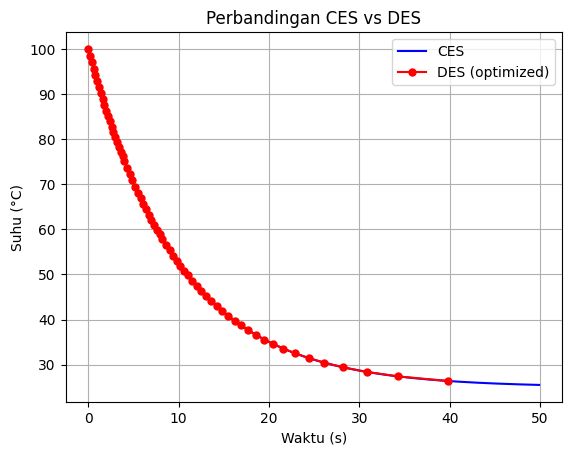

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter umum
T0 = 100  # Suhu awal benda (derajat Celsius)
Tamb = 25  # Suhu lingkungan (derajat Celsius)
k = 0.1   # Konstanta laju pendinginan
dt = 0.1  # Langkah waktu untuk CES
t_max = 50  # Waktu simulasi maksimum

# Inisialisasi array untuk CES
time = np.arange(0, t_max, dt)
T_ces = np.zeros(len(time))
T_ces[0] = T0

# Simulasi CES (Continuous Event Simulation)
for i in range(1, len(time)):
    dT_dt = -k * (T_ces[i-1] - Tamb)
    T_ces[i] = T_ces[i-1] + dT_dt * dt

# Simulasi DES (Discrete Event Simulation) yang dioptimalkan
T_des = [T0]
time_des = [0]
current_T = T0
current_t = 0
threshold = 1.0  # Perubahan suhu minimum untuk mencatat peristiwa (dalam °C)
max_steps = 1000  # Batas iterasi untuk mencegah loop tak terbatas

while current_T > Tamb + 0.1 and current_t < t_max and len(time_des) < max_steps:
    dT_dt = -k * (current_T - Tamb)
    delta_T = dT_dt * dt
    current_T += delta_T
    current_t += dt
    # Catat hanya jika perubahan suhu signifikan
    if abs(current_T - T_des[-1]) >= threshold or current_T <= Tamb + 0.1:
        T_des.append(current_T)
        time_des.append(current_t)

# Plot perbandingan
plt.plot(time, T_ces, label='CES', color='blue')
plt.plot(time_des, T_des, 'o-', label='DES (optimized)', color='red', markersize=5)
plt.xlabel('Waktu (s)')
plt.ylabel('Suhu (°C)')
plt.title('Perbandingan CES vs DES')
plt.legend()
plt.grid()
plt.show()